<a href="https://colab.research.google.com/github/TommasoG85/Surplexity/blob/main/Surplexity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Qwen/Qwen2.5-1.5B... this may take a minute.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Fetching data from databases and APIs...
Attempting to fetch from Federal Register API (Open Legal Data)...
Federal Register API failed: object of type 'NoneType' has no len(). Using fallback.
Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...
Nigerian Pidgin text successfully fetched from 'masakhane/masakhanews'.


Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.


Calculating surplexity scores...

  DOCUMENTS ORDERED BY SURPLEXITY
1. Python Code      | Surplexity:       3.95
2. Synthetic (AI)   | Surplexity:       9.62
3. Simple Wiki      | Surplexity:      14.00
4. Open Legal       | Surplexity:      74.50
5. Finnegans Wake   | Surplexity:      87.00
6. Nigerian pidgin  | Surplexity:     216.00
7. Random Tokens    | Surplexity: 1,130,496.00

Complete. Displaying heatmaps...


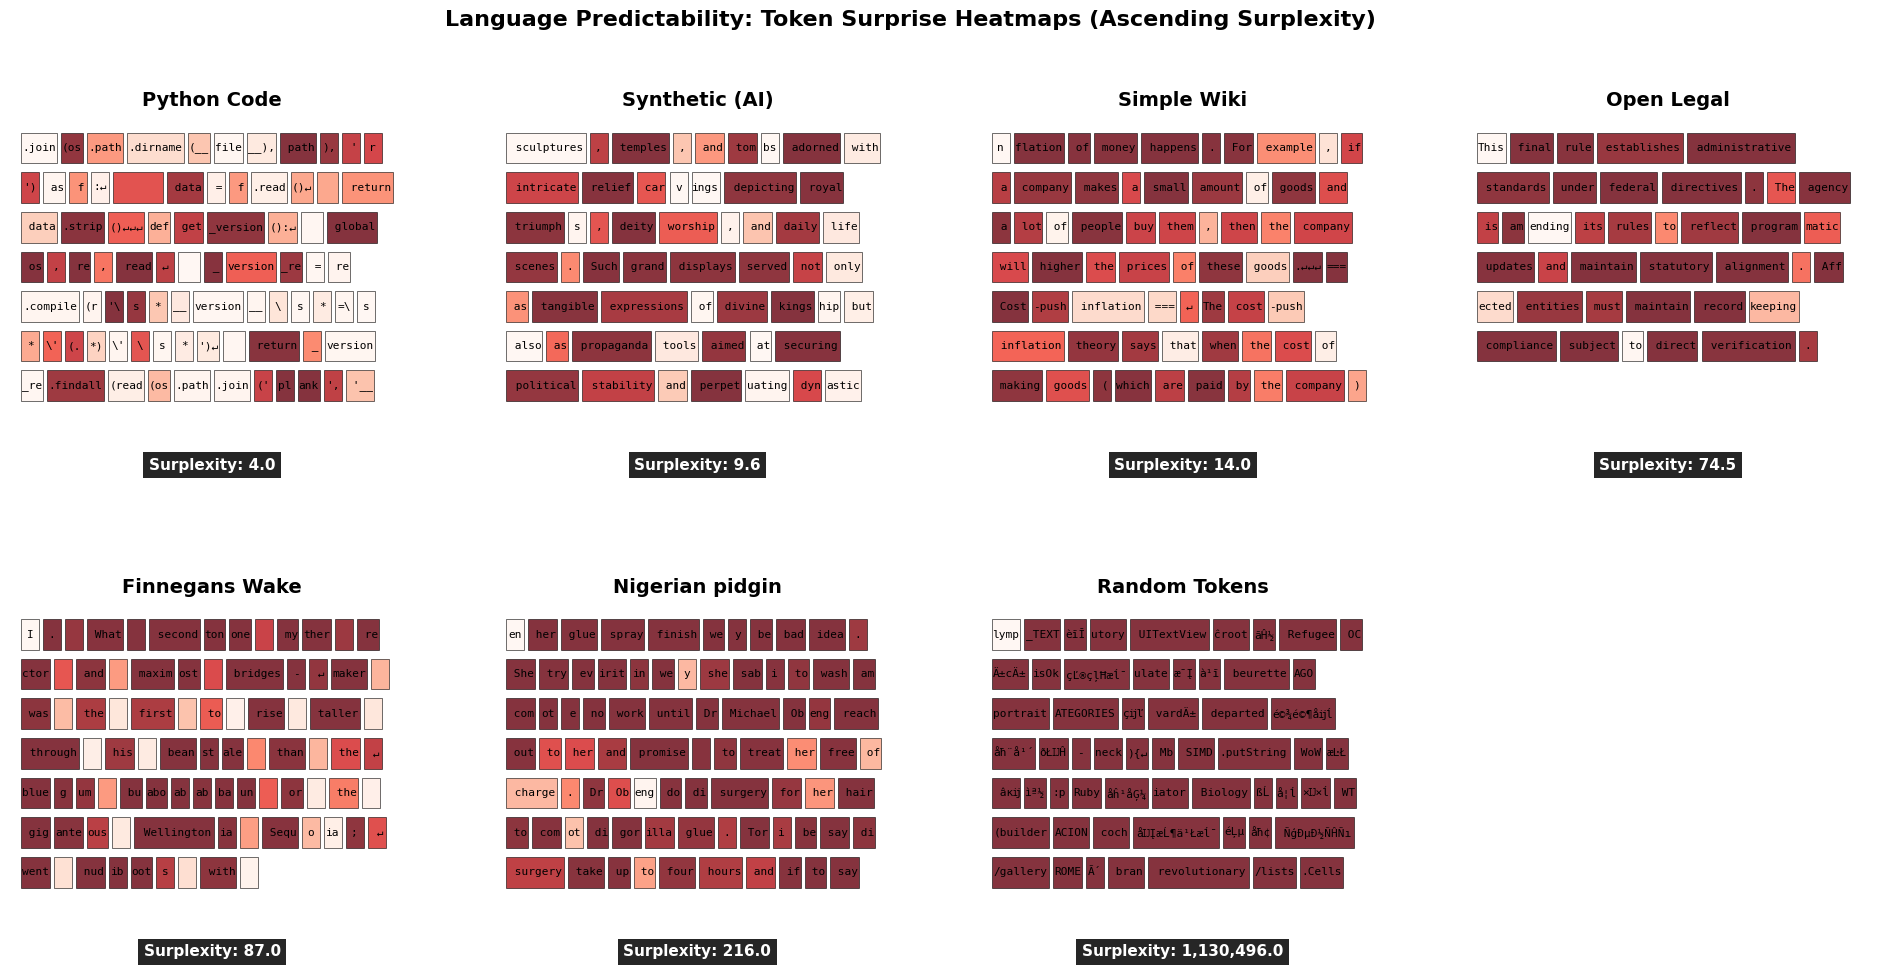

In [ ]:
import random
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- 1. Setup ---
model_name = "Qwen/Qwen2.5-1.5B"

print(f"Loading {model_name}... this may take a minute.")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype="auto", device_map="auto"
)
model.eval()

# --- Helper: Mid-Document Sampling ---

def get_middle_text_slice(text: str, target_chars: int = 1500, skip_ratio: float = 0.3) -> str:
    """
    Extracts a slice from the middle of a text document to bypass
    license headers, chapter titles, and lead sentences.
    """
    total_len = len(text)
    if total_len <= target_chars:
        return text

    start_idx = int(total_len * skip_ratio)
    end_idx = min(total_len, start_idx + target_chars)

    if (end_idx - start_idx) < target_chars:
        start_idx = max(0, total_len - target_chars)
        end_idx = total_len

    return text[start_idx:end_idx]


# --- 2. Data Fetching Functions ---

def get_wiki():
    # Uses Wikipedia Query API to fetch full plaintext articles (not just summary leads)
    url = "https://simple.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "generator": "random",
        "grnnamespace": 0,
        "prop": "extracts",
        "explaintext": 1,
        "format": "json"
    }
    headers = {"User-Agent": "SurplexityBot/2.0"}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        pages = r.json().get("query", {}).get("pages", {})
        for _, page in pages.items():
            extract = page.get("extract", "")
            if len(extract) > 800:
                return get_middle_text_slice(extract, target_chars=1200, skip_ratio=0.35)
    except Exception:
        pass

    fallback = (
        "Earth is the third planet from the Sun and the only astronomical object known "
        "to harbor life. High-density liquid water covers approximately 70.8% of the surface. "
        "The remaining land area consists of continents and islands with diverse topographical features."
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.2)


def get_joyce():
    url = "https://archive.org/stream/finneganswake00joycuoft/finneganswake00joycuoft_djvu.txt"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=15)
        paragraphs = [
            p.strip()
            for p in response.text.split("\n\n")
            if len(p.strip()) > 200
        ]
        # Ignore top 15% of paragraphs to avoid title/copyright text
        start_offset = int(len(paragraphs) * 0.15)
        selected_para = random.choice(paragraphs[start_offset:])
        return get_middle_text_slice(selected_para, target_chars=1200, skip_ratio=0.2)
    except Exception:
        fallback = "riverrun, past Eve and Adam's, from swerve of shore to bend of bay, brings us by a commodius vicus of recirculation back to Howth Castle and Environs."
        return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_ai_generated():
    try:
        ds = load_dataset(
            "HuggingFaceTB/cosmopedia-v2",
            name="cosmopedia-v2",
            split="train",
            streaming=True,
        )
        for item in ds.shuffle(buffer_size=100):
            text = item.get("text", "")
            if len(text) > 1500:
                # Skip first 30% to bypass "Chapter X:" or "Introduction" blocks
                return get_middle_text_slice(text, target_chars=1200, skip_ratio=0.30)
    except Exception:
        pass

    fallback = "The concept of synthetic data involves creating information algorithmically to mimic real-world datasets for downstream model optimization and structural validation."
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_nigerian_pidgin():
    print("Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...")
    dataset_options = [
        ("masakhane/masakhanews", "pcm", "text"),
        ("facebook/flores", "pcm_Latn", "sentence"),
    ]

    for ds_name, config, text_key in dataset_options:
        try:
            ds = load_dataset(ds_name, config, split="train", streaming=True)
            accumulated_text = []
            current_len = 0

            for item in ds.shuffle(buffer_size=50):
                content = (
                    item.get(text_key)
                    or item.get("headline")
                    or item.get("text")
                )
                if content and len(content.strip()) > 20:
                    clean_text = content.strip()
                    accumulated_text.append(clean_text)
                    current_len += len(clean_text) + 1

                    if current_len >= 1500:
                        full_text = " ".join(accumulated_text)
                        print(f"Nigerian Pidgin text successfully fetched from '{ds_name}'.")
                        return get_middle_text_slice(full_text, target_chars=1200, skip_ratio=0.25)
        except Exception:
            continue

    print("Stream failed. Using Nigerian Pidgin fallback passage.")
    fallback = (
        "People for different part of Nigeria dey cry say food item cost "
        "for market don high well well dis month. Plenty market woman "
        "explain say transport money and bad road na de main reason "
        "why price of garri, rice, and tomato dey jump every week. "
        "Gofment don promise say dem go quickly release grain from reserve "
        "to help reduce the suffer wey citizens dey face."
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_open_legal_data():
    print("Attempting to fetch from Federal Register API (Open Legal Data)...")
    random_page = random.randint(1, 10)
    url = f"https://www.federalregister.gov/api/v1/documents.json?per_page=20&page={random_page}"

    try:
        r = requests.get(url, timeout=10)
        docs = r.json().get("results", [])
        random.shuffle(docs)

        for doc in docs:
            abstract = doc.get("abstract", "")
            if len(abstract) > 500:
                print(f"Legal data successfully fetched (Page {random_page}).")
                return get_middle_text_slice(abstract, target_chars=1200, skip_ratio=0.25)
    except Exception as e:
        print(f"Federal Register API failed: {e}. Using fallback.")

    fallback = (
        "This final rule establishes administrative standards under federal directives. "
        "The agency is amending its rules to reflect programmatic updates and maintain statutory alignment. "
        "Affected entities must maintain recordkeeping compliance subject to direct verification."
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_code_snippet():
    try:
        ds = load_dataset(
            "codeparrot/codeparrot-clean-valid", split="train", streaming=True
        )
        for item in ds.shuffle(buffer_size=100):
            code = item["content"]
            if len(code) > 1200 and "def " in code:
                # Skip first 30% to purge license headers and module docstrings
                return get_middle_text_slice(code, target_chars=1200, skip_ratio=0.30)
    except Exception:
        pass

    fallback = (
        "def compute_gradients(weights, inputs, targets):\n"
        "    predictions = np.dot(inputs, weights)\n"
        "    error = predictions - targets\n"
        "    grad = np.dot(inputs.T, error) / len(targets)\n"
        "    return grad"
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_random_sequence(length=85):
    vocab_size = tokenizer.vocab_size
    random_ids = [random.randint(0, vocab_size - 1) for _ in range(length)]
    return tokenizer.decode(random_ids)


# --- 3. Token Statistics & Heatmap ---

def get_token_stats(text, max_tokens=85):
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=max_tokens + 1
    )
    if inputs["input_ids"].shape[1] < 2:
        return ["Error"], [1.0], 0.0

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        logits = outputs.logits[:, :-1, :]
        target_ids = inputs["input_ids"][:, 1:]
        probs = torch.softmax(logits, dim=-1)
        token_probs = torch.gather(probs, 2, target_ids.unsqueeze(-1)).squeeze()
        loss = torch.nn.CrossEntropyLoss()(
            logits.view(-1, logits.size(-1)), target_ids.view(-1)
        )
        surplexity = torch.exp(loss).item()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    raw_probs = (
        token_probs.tolist()
        if token_probs.dim() > 0
        else [token_probs.item()]
    )
    display_probs = [1.0] + raw_probs
    return tokens[:max_tokens], display_probs[:max_tokens], surplexity


def plot_heatmap(text, source_name, ax, token_limit=85):
    tokens, probs, surp = get_token_stats(text, max_tokens=token_limit)

    ax.set_xlim(0, 180)
    ax.set_ylim(0, 100)
    ax.axis("off")

    x_cursor, y_cursor = 5, 88
    line_height, char_width = 11.0, 3.2
    ax.set_title(f"{source_name}", fontweight="bold", fontsize=14, pad=10)

    for token, prob in zip(tokens, probs):
        clean_token = token.replace("Ġ", " ").replace("Ċ", "↵")
        token_len = max(len(clean_token) * char_width, 8.0)

        if x_cursor + token_len > 172:
            x_cursor = 5
            y_cursor -= line_height

        if y_cursor < 15:
            break

        color = plt.cm.Reds(1.0 - prob)
        rect = patches.Rectangle(
            (x_cursor, y_cursor),
            token_len,
            8.5,
            edgecolor="black",
            facecolor=color,
            alpha=0.8,
            linewidth=0.5,
        )
        ax.add_patch(rect)
        ax.text(
            x_cursor + (token_len / 2),
            y_cursor + 4.25,
            clean_token,
            ha="center",
            va="center",
            fontsize=8,
            family="monospace",
        )
        x_cursor += token_len + 1.8

    ax.text(
        90,
        3,
        f"Surplexity: {surp:,.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor="black", alpha=0.85, edgecolor="none", pad=4),
    )


# --- 4. Execution ---

print("Fetching data from databases and APIs...")
raw_docs = [
    ("Simple Wiki", get_wiki()),
    ("Finnegans Wake", get_joyce()),
    ("Open Legal", get_open_legal_data()),
    ("Nigerian pidgin", get_nigerian_pidgin()),
    ("Synthetic (AI)", get_ai_generated()),
    ("Python Code", get_code_snippet()),
    ("Random Tokens", get_random_sequence()),
]

print("Calculating surplexity scores...")
docs = []
for name, text in raw_docs:
    _, _, surp = get_token_stats(text)
    docs.append((surp, name, text))

docs.sort(key=lambda item: item[0])

print("\n" + "=" * 40)
print("  DOCUMENTS ORDERED BY SURPLEXITY")
print("=" * 40)
for rank, (surp, name, _) in enumerate(docs, 1):
    print(f"{rank}. {name:<16} | Surplexity: {surp:>10,.2f}")
print("=" * 40 + "\n")

n_docs = len(docs)
n_cols = 4
n_rows = 2

fig = plt.figure(figsize=(24, 11))
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.35, wspace=0.20)

for i, (surp, name, text) in enumerate(docs):
    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])
    plot_heatmap(text, name, ax)

for i in range(n_docs, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])
    ax.axis("off")

plt.suptitle(
    "Language Predictability: Token Surprise Heatmaps (Ascending Surplexity)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

print("Complete. Displaying heatmaps...")
plt.show()


Loading Qwen/Qwen2.5-1.5B... this may take a minute.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Fetching data from databases and APIs...
Attempting to fetch from Federal Register API (Open Legal Data)...
Legal data successfully fetched (Page 4).
Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...
Nigerian Pidgin text successfully fetched from 'masakhane/masakhanews'.


Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.


Calculating surplexity scores and sorting...

  DOCUMENTS ORDERED BY SURPLEXITY
1. Python Code      | Surplexity:       5.31
2. Open Legal       | Surplexity:       5.44
3. Simple Wiki      | Surplexity:       6.78
4. Synthetic (AI)   | Surplexity:       7.09
5. Finnegans Wake   | Surplexity:      31.12
6. Nigerian pidgin  | Surplexity:     148.00
7. Random Tokens    | Surplexity: 684,032.00

Complete. Displaying analysis...


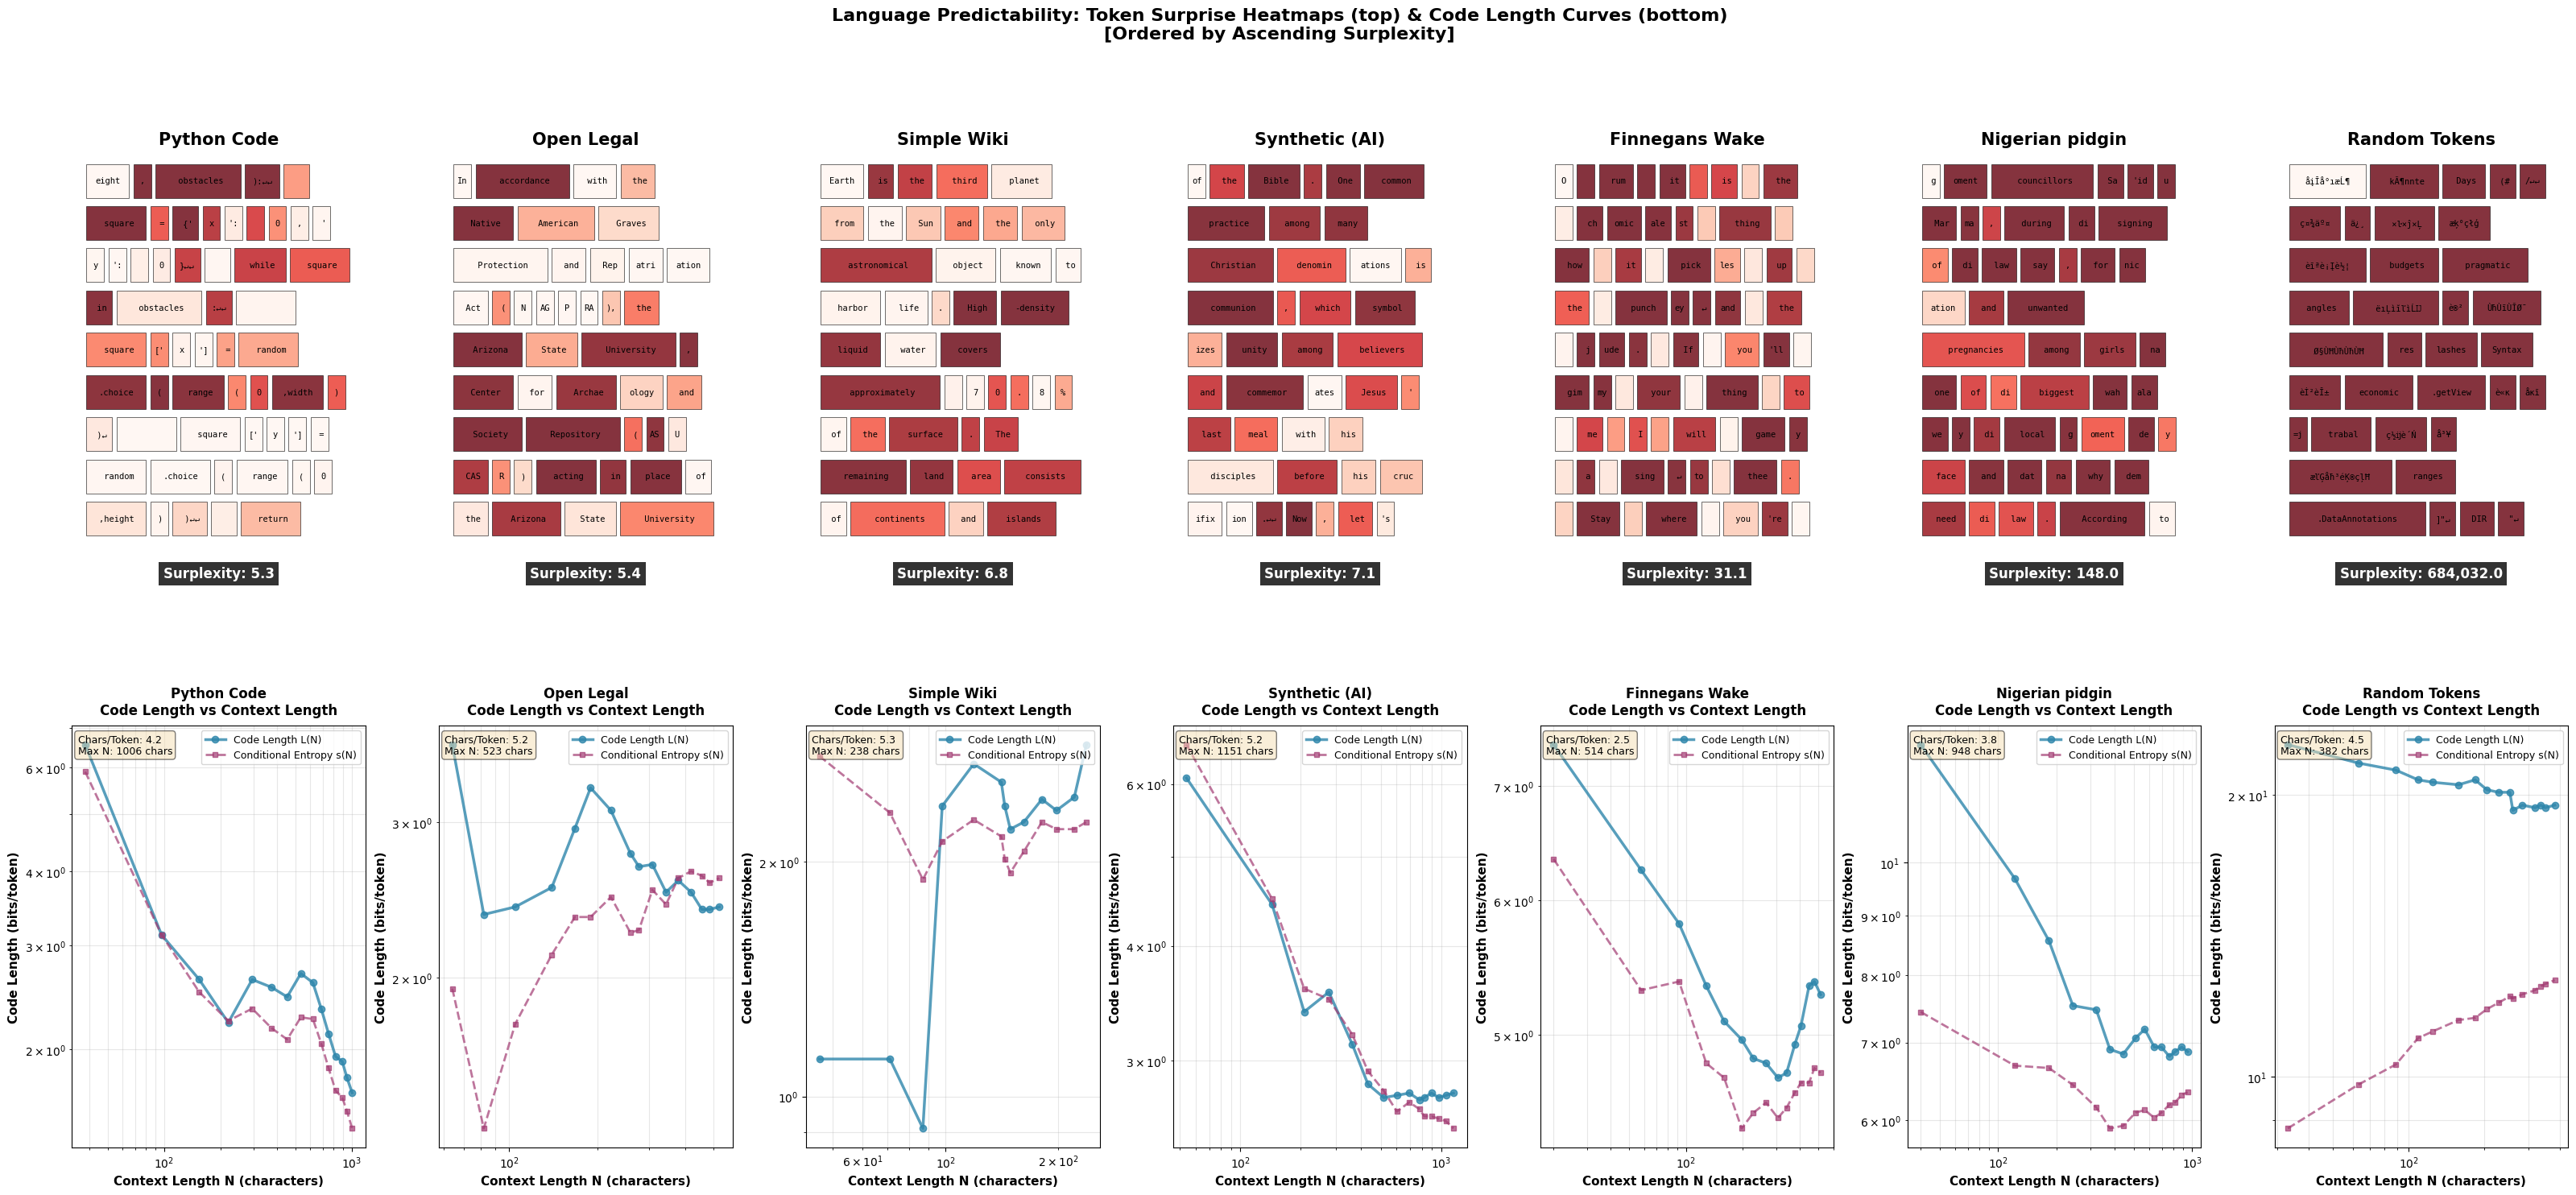

In [11]:
import random
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- 1. Setup ---
model_name = "Qwen/Qwen2.5-1.5B"

print(f"Loading {model_name}... this may take a minute.")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype="auto", device_map="auto"
)
model.eval()

# --- Helper: Mid-Document Sampling Protocol ---

def get_middle_text_slice(text: str, target_chars: int = 1500, skip_ratio: float = 0.3) -> str:
    """
    Extracts a slice from the middle of a text document to bypass
    license headers, chapter titles, and lead sentences.
    """
    total_len = len(text)
    if total_len <= target_chars:
        return text

    start_idx = int(total_len * skip_ratio)
    end_idx = min(total_len, start_idx + target_chars)

    if (end_idx - start_idx) < target_chars:
        start_idx = max(0, total_len - target_chars)
        end_idx = total_len

    return text[start_idx:end_idx]


# --- 2. Data Fetching Functions ---

def get_wiki():
    # Uses Wikipedia Query API to fetch full plaintext articles (bypassing introductory summaries)
    url = "https://simple.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "generator": "random",
        "grnnamespace": 0,
        "prop": "extracts",
        "explaintext": 1,
        "format": "json"
    }
    headers = {"User-Agent": "SurplexityBot/2.0"}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        pages = r.json().get("query", {}).get("pages", {})
        for _, page in pages.items():
            extract = page.get("extract", "")
            if len(extract) > 800:
                return get_middle_text_slice(extract, target_chars=1200, skip_ratio=0.35)
    except Exception:
        pass

    fallback = (
        "Earth is the third planet from the Sun and the only astronomical object known "
        "to harbor life. High-density liquid water covers approximately 70.8% of the surface. "
        "The remaining land area consists of continents and islands with diverse topographical features."
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.2)


def get_joyce():
    url = "https://archive.org/stream/finneganswake00joycuoft/finneganswake00joycuoft_djvu.txt"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=15)
        paragraphs = [
            p.strip() for p in response.text.split("\n\n") if len(p.strip()) > 200
        ]
        # Ignore top 15% of paragraphs to avoid title/copyright text
        start_offset = int(len(paragraphs) * 0.15)
        selected_para = random.choice(paragraphs[start_offset:])
        return get_middle_text_slice(selected_para, target_chars=1200, skip_ratio=0.2)
    except Exception:
        fallback = "riverrun, past Eve and Adam's, from swerve of shore to bend of bay, brings us by a commodius vicus of recirculation back to Howth Castle and Environs."
        return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_ai_generated():
    try:
        ds = load_dataset(
            "HuggingFaceTB/cosmopedia-v2",
            name="cosmopedia-v2",
            split="train",
            streaming=True,
        )
        for item in ds.shuffle(buffer_size=100):
            text = item.get("text", "")
            if len(text) > 1500:
                # Skip first 30% to bypass "Chapter X:" or "Introduction" blocks
                return get_middle_text_slice(text, target_chars=1200, skip_ratio=0.30)
    except Exception:
        pass

    fallback = "The concept of synthetic data involves creating information algorithmically to mimic real-world datasets for downstream model optimization and structural validation."
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_open_legal_data():
    print("Attempting to fetch from Federal Register API (Open Legal Data)...")
    random_page = random.randint(1, 10)
    url = f"https://www.federalregister.gov/api/v1/documents.json?per_page=20&page={random_page}"

    try:
        r = requests.get(url, timeout=10)
        docs = r.json().get("results", [])
        random.shuffle(docs)

        for doc in docs:
            abstract = doc.get("abstract", "")
            if len(abstract) > 500:
                print(f"Legal data successfully fetched (Page {random_page}).")
                return get_middle_text_slice(abstract, target_chars=1200, skip_ratio=0.25)
    except Exception as e:
        print(f"Federal Register API failed: {e}. Using fallback.")

    fallback = (
        "This final rule establishes administrative standards under federal directives. "
        "The agency is amending its rules to reflect programmatic updates and maintain statutory alignment. "
        "Affected entities must maintain recordkeeping compliance subject to direct verification."
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_nigerian_pidgin():
    print("Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...")
    dataset_options = [
        ("masakhane/masakhanews", "pcm", "text"),
        ("facebook/flores", "pcm_Latn", "sentence"),
    ]

    for ds_name, config, text_key in dataset_options:
        try:
            ds = load_dataset(ds_name, config, split="train", streaming=True)
            accumulated_text = []
            current_len = 0

            for item in ds.shuffle(buffer_size=50):
                content = (
                    item.get(text_key)
                    or item.get("headline")
                    or item.get("text")
                )
                if content and len(content.strip()) > 20:
                    clean_text = content.strip()
                    accumulated_text.append(clean_text)
                    current_len += len(clean_text) + 1

                    if current_len >= 1500:
                        full_text = " ".join(accumulated_text)
                        print(f"Nigerian Pidgin text successfully fetched from '{ds_name}'.")
                        return get_middle_text_slice(full_text, target_chars=1200, skip_ratio=0.25)
        except Exception:
            continue

    print("Stream failed. Using Nigerian Pidgin fallback passage.")
    fallback = (
        "People for different part of Nigeria dey cry say food item cost "
        "for market don high well well dis month. Plenty market woman "
        "explain say transport money and bad road na de main reason "
        "why price of garri, rice, and tomato dey jump every week. "
        "Gofment don promise say dem go quickly release grain from reserve "
        "to help reduce the suffer wey citizens dey face."
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_code_snippet():
    try:
        ds = load_dataset(
            "codeparrot/codeparrot-clean-valid", split="train", streaming=True
        )
        for item in ds.shuffle(buffer_size=100):
            code = item["content"]
            if len(code) > 1200 and "def " in code:
                # Skip first 30% to purge license headers and module docstrings
                return get_middle_text_slice(code, target_chars=1200, skip_ratio=0.30)
    except Exception:
        pass

    fallback = (
        "def compute_gradients(weights, inputs, targets):\n"
        "    predictions = np.dot(inputs, weights)\n"
        "    error = predictions - targets\n"
        "    grad = np.dot(inputs.T, error) / len(targets)\n"
        "    return grad"
    )
    return get_middle_text_slice(fallback, target_chars=1200, skip_ratio=0.1)


def get_random_sequence(length=85):
    vocab_size = tokenizer.vocab_size
    random_ids = [random.randint(0, vocab_size - 1) for _ in range(length)]
    return tokenizer.decode(random_ids)


# --- 3. Code Length & Context Analysis ---

def get_code_length_curve_optimized(text, max_tokens=256):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_tokens)
    input_ids = inputs["input_ids"].to(model.device)

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[:, :-1, :]
        targets = input_ids[:, 1:]

        log_probs = torch.log_softmax(logits, dim=-1)
        token_log_probs = torch.gather(log_probs, 2, targets.unsqueeze(-1)).squeeze()
        all_bits = -token_log_probs / np.log(2)

        probs = torch.softmax(logits, dim=-1)
        all_entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).squeeze()

    N_vals, L_vals, s_vals = [], [], []
    step = max(1, len(all_bits) // 15)
    for i in range(10, len(all_bits), step):
        N_vals.append(len(tokenizer.decode(input_ids[0, :i])))
        L_vals.append(all_bits[:i].mean().item())
        s_vals.append(all_entropy[:i].mean().item())

    return np.array(N_vals), np.array(L_vals), np.array(s_vals)


def plot_code_length_analysis(text, source_name, ax):
    try:
        N_vals, L_vals, s_vals = get_code_length_curve_optimized(text, max_tokens=256)

        if len(N_vals) < 2:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
            return

        ax.loglog(N_vals, L_vals, "o-", linewidth=2.5, markersize=6,
                  color="#2E86AB", label="Code Length L(N)", alpha=0.8)
        ax.loglog(N_vals, s_vals, "s--", linewidth=2, markersize=5,
                  color="#A23B72", label="Conditional Entropy s(N)", alpha=0.7)

        ax.set_xlabel("Context Length N (characters)", fontsize=11, fontweight="bold")
        ax.set_ylabel("Code Length (bits/token)", fontsize=11, fontweight="bold")
        ax.set_title(f"{source_name}\nCode Length vs Context Length",
                     fontsize=12, fontweight="bold", pad=10)
        ax.grid(True, alpha=0.3, which="both")
        ax.legend(fontsize=9, loc="upper right")

        char_per_token = len(text) / len(tokenizer.encode(text))
        stats_text = f"Chars/Token: {char_per_token:.1f}\nMax N: {N_vals[-1]:.0f} chars"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    except Exception as e:
        print(f"Error in {source_name}: {e}")
        ax.text(0.5, 0.5, f"Error: {str(e)[:30]}", ha="center", va="center",
                transform=ax.transAxes, fontsize=10)


# --- 4. Token Statistics ---

def get_token_stats(text, max_tokens=85):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_tokens + 1)
    if inputs["input_ids"].shape[1] < 2:
        return ["Error"], [1.0], 0.0

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        logits = outputs.logits[:, :-1, :]
        target_ids = inputs["input_ids"][:, 1:]
        probs = torch.softmax(logits, dim=-1)
        token_probs = torch.gather(probs, 2, target_ids.unsqueeze(-1)).squeeze()
        loss = torch.nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), target_ids.view(-1))
        surplexity = torch.exp(loss).item()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    raw_probs = token_probs.tolist() if token_probs.dim() > 0 else [token_probs.item()]
    display_probs = [1.0] + raw_probs
    return tokens[:max_tokens], display_probs[:max_tokens], surplexity


def plot_heatmap(text, source_name, ax, token_limit=85):
    tokens, probs, surp = get_token_stats(text, max_tokens=token_limit)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")

    x_cursor, y_cursor = 5, 90
    line_height, char_width = 10.0, 2.9
    ax.set_title(f"{source_name}", fontweight="bold", fontsize=15, pad=10)
    ax.text(50, 0, f"Surplexity: {surp:,.1f}", ha="center", fontsize=12, fontweight="bold",
            color="white", bbox=dict(facecolor="black", alpha=0.8, edgecolor="none"))

    for token, prob in zip(tokens, probs):
        clean_token = token.replace("Ġ", " ").replace("Ċ", "↵")
        token_len = max(len(clean_token) * char_width, 6.0)
        if x_cursor + token_len > 95:
            x_cursor, y_cursor = 5, y_cursor - line_height
        if y_cursor < 10:
            break

        color = plt.cm.Reds(1.0 - prob)
        rect = patches.Rectangle((x_cursor, y_cursor), token_len, 8,
                                 edgecolor="black", facecolor=color, alpha=0.8, linewidth=0.5)
        ax.add_patch(rect)
        ax.text(x_cursor + (token_len / 2), y_cursor + 4, clean_token,
                ha="center", va="center", fontsize=7.5, family="monospace")
        x_cursor += token_len + 1.5


# --- 5. Execution ---

print("Fetching data from databases and APIs...")
raw_docs = [
    ("Simple Wiki", get_wiki()),
    ("Finnegans Wake", get_joyce()),
    ("Open Legal", get_open_legal_data()),
    ("Nigerian pidgin", get_nigerian_pidgin()),
    ("Synthetic (AI)", get_ai_generated()),
    ("Python Code", get_code_snippet()),
    ("Random Tokens", get_random_sequence()),
]

print("Calculating surplexity scores and sorting...")
docs = []
for name, text in raw_docs:
    _, _, surp = get_token_stats(text)
    docs.append((surp, name, text))

docs.sort(key=lambda item: item[0])

print("\n" + "=" * 40)
print("  DOCUMENTS ORDERED BY SURPLEXITY")
print("=" * 40)
for rank, (surp, name, _) in enumerate(docs, 1):
    print(f"{rank}. {name:<16} | Surplexity: {surp:>10,.2f}")
print("=" * 40 + "\n")

# Dual-row visualization (Heatmaps top row, Code Length Curves bottom row)
fig = plt.figure(figsize=(40, 16))
gs = fig.add_gridspec(2, len(docs), hspace=0.35, wspace=0.25)

for i, (surp, name, text) in enumerate(docs):
    # Heatmap (top row)
    ax_heatmap = fig.add_subplot(gs[0, i])
    plot_heatmap(text, name, ax_heatmap)

    # Code length curve (bottom row)
    ax_curve = fig.add_subplot(gs[1, i])
    plot_code_length_analysis(text, name, ax_curve)

plt.suptitle(
    "Language Predictability: Token Surprise Heatmaps (top) & Code Length Curves (bottom)\n[Ordered by Ascending Surplexity]",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

print("Complete. Displaying analysis...")
plt.show()